








# Assignment 1 - MLP from Scratch on the Iris Dataset

**Anjananand Iragavarapu** · Applied AIML 2 · a1987826

I built a multilayer perceptron with 4 inputs, 16 hidden units using ReLU, and 3 output units
using softmax. I used scikit-learn only to load the dataset, split
it, and standardise the features.

I trained it with the settings given in the brief batch size 16, learning rate 0.01, 100
epochs, and an 80/20 train-test split.

## 1. Data Loading and Preprocessing

I standardised the features to zero mean and unit variance. I did this because the four measurements sit on quite different scales, sepal
length runs from about 4 to 8 centimetres while petal width only spans 0.1 to 2.5. With one
learning rate shared across all weights, that mismatch means some directions get over-stepped.

I also preferred standardising because it centres the inputs around zero, which suits ReLU.

I fitted the scaler on the training set only, then applied those same statistics to the test
set.

I stratified the split so each class contributes exactly ten samples to the test set. I did
this because with only 30 test samples, an uneven draw would make the accuracy figure hard
to trust.

I one-hot encoded the labels so they match the shape of what the softmax layer outputs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42                                 
N_INPUT, N_HIDDEN, N_OUTPUT = 4, 16, 3              # architecture from the brief
EPOCHS, BATCH_SIZE, LEARNING_RATE = 100, 16, 0.01   # training settings from the brief

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# turn integer labels into one-hot rows
def one_hot(y, num_classes=N_OUTPUT):
    return np.eye(num_classes)[y]              # each label picks one row of the identity matrix


# load Iris, split it, standardise the features, one-hot the labels
def load_and_preprocess(test_size=0.2, seed=RANDOM_SEED):
    X, y = load_iris(return_X_y=True)         


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=seed
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)    # learn mean and spread from training data
    X_test = scaler.transform(X_test)       # apply the same numbers, never refit

    return X_train, X_test, one_hot(y_train), one_hot(y_test), y_train, y_test

In [3]:
X_train, X_test, Y_train, Y_test, y_train, y_test = load_and_preprocess()

print("Features :", X_train.shape, X_test.shape)
print("Labels   :", Y_train.shape, Y_test.shape)
print("Train mean:", X_train.mean(axis=0).round(3), "| std:", X_train.std(axis=0).round(3))
print("Test mean :", X_test.mean(axis=0).round(3), "  <- close to zero but not exactly")
print("Test class counts:", np.bincount(y_test))

Features : (120, 4) (30, 4)
Labels   : (120, 3) (30, 3)
Train mean: [-0. -0.  0.  0.] | std: [1. 1. 1. 1.]
Test mean : [ 0.01   0.101 -0.034 -0.037]   <- close to zero but not exactly
Test class counts: [10 10 10]


 I expected the training
features to come out with mean zero and standard deviation one, and they do.

I also expected the test features to be close to zero but not exactly zero, and that is what I
got. 
## 2. Activations and Loss

I used ReLU on the hidden layer, which simply passes a value through if it is positive and
returns zero otherwise.

I used softmax on the output layer to turn the three raw scores into probabilities that sum to
one.



In [4]:
# ReLU: keep positives, zero out negatives
def relu(z):
    return np.maximum(0.0, z)


# gradient of ReLU: 1 where the unit is active, 0 where it isn't
def relu_derivative(z):
    return (z > 0).astype(float)               # taken as 0 at exactly zero, by convention


# turn each row of scores into probabilities that sum to one
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))   # stops exp() overflowing
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


# average cross-entropy across the batch
def cross_entropy_loss(Y_pred, Y_true, eps=1e-12):
    Y_pred = np.clip(Y_pred, eps, 1.0)                     
    return -np.mean(np.sum(Y_true * np.log(Y_pred), axis=1))


# fraction of samples predicted correctly
def accuracy(y_pred, y_true):
    return float(np.mean(y_pred == y_true))

In [5]:
#  softmax demo
z = np.array([[1000.0, 1.0, 1.0]])

with np.errstate(over="ignore", invalid="ignore"):
    print("Without the shift:", np.exp(z) / np.sum(np.exp(z)), " <- overflowed to NaN")

print("With the shift   :", softmax(z))

Without the shift: [[nan  0.  0.]]  <- overflowed to NaN
With the shift   : [[1. 0. 0.]]


## 3. The MLP Class

 I multiply the input batch by the first weight matrix and add
the first bias, which gives the hidden layer's raw scores. I push those through ReLU. I then
multiply the result by the second weight matrix, add the second bias, and push that through
softmax to get class probabilities. 

I used He initialisation, which draws the weights from a
normal distribution scaled by the square root of two divided by a layer size, with the biases
starting at zero.

In [6]:
# two-layer MLP
class MLP:

    def __init__(self, n_input=N_INPUT, n_hidden=N_HIDDEN, n_output=N_OUTPUT,
                 seed=RANDOM_SEED):
        rng = np.random.default_rng(seed)

        std1 = np.sqrt(2.0 / n_input)          # sized by inputs
        std2 = np.sqrt(2.0 / n_output)         # sized by outputs

        self.W1 = rng.standard_normal((n_input, n_hidden)) * std1
        self.b1 = np.zeros((1, n_hidden))      # biases start at zero
        self.W2 = rng.standard_normal((n_hidden, n_output)) * std2
        self.b2 = np.zeros((1, n_output))
        self.cache = {}                        # holds forward values needed by backward

    # run a batch through the network and remember the intermediate values
    def forward(self, X):
        Z1 = X @ self.W1 + self.b1             # hidden scores
        A1 = relu(Z1)                          # hidden activations
        Z2 = A1 @ self.W2 + self.b2            # output scores
        A2 = softmax(Z2)                       # class probabilities

        self.cache = {"X": X, "Z1": Z1, "A1": A1, "A2": A2}
        return A2

    # work backwards from the loss and return a gradient for every parameter
    def backward(self, Y):
        X, Z1, A1, A2 = (self.cache["X"], self.cache["Z1"],
                         self.cache["A1"], self.cache["A2"])
        m = X.shape[0]

        dZ2 = (A2 - Y) / m                     # softmax and cross-entropy collapse to this
        dW2 = A1.T @ dZ2
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_derivative(Z1)        # zero out wherever the unit was inactive
        dW1 = X.T @ dZ1
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

    # nudge every parameter a small step against its gradient
    def sgd_step(self, grads, learning_rate):
        self.W1 -= learning_rate * grads["W1"]
        self.b1 -= learning_rate * grads["b1"]
        self.W2 -= learning_rate * grads["W2"]
        self.b2 -= learning_rate * grads["b2"]

    # class probabilities for a batch
    def predict_proba(self, X):
        return self.forward(X)

    # predicted class label for each sample
    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)   # pick the highest-probability class

## 4. Checking the Gradients

I checked my backward pass against numerical gradients before training anything. 

I nudge one weight up by a tiny amount, measure the loss,
nudge it down by the same amount, measure again, and divide the difference by the total nudge.


In [7]:
# comparing my analytical gradients against numerically estimated ones
def gradient_check(model, X, Y, eps=1e-6, n_samples=25, seed=0, tiny=1e-5):
    rng = np.random.default_rng(seed)
    model.forward(X)
    grads = model.backward(Y)
    rel_errors = []

    for name in ["W1", "b1", "W2", "b2"]:
        P = getattr(model, name)

        # check a random sample of entries 
        for f in rng.choice(P.size, size=min(n_samples, P.size), replace=False):
            idx = np.unravel_index(f, P.shape)
            original = P[idx]

            P[idx] = original + eps                              # nudge up
            loss_plus = cross_entropy_loss(model.forward(X), Y)
            P[idx] = original - eps                              # nudge down
            loss_minus = cross_entropy_loss(model.forward(X), Y)
            P[idx] = original                                   

            numerical = (loss_plus - loss_minus) / (2 * eps)     
            analytical = grads[name][idx]

           
            if max(abs(numerical), abs(analytical)) > tiny:
                rel_errors.append(abs(numerical - analytical) /
                                  (abs(numerical) + abs(analytical)))

    return max(rel_errors)


worst = gradient_check(MLP(seed=0), X_train[:8], Y_train[:8])
print(f"Worst relative error: {worst:.2e}")
print("PASS - my backward pass agrees with the numerical estimate" if worst < 1e-6 else "FAIL")

Worst relative error: 1.73e-08
PASS - my backward pass agrees with the numerical estimate


## 5. Training Loop

I trained with mini-batch stochastic gradient descent using the settings from the brief.



In [8]:
# train with mini-batch SGD and record loss and accuracy each epoch
def train(model, X_train, Y_train, y_train, X_test, Y_test, y_test,
          epochs=EPOCHS, batch_size=BATCH_SIZE, learning_rate=LEARNING_RATE,
          seed=RANDOM_SEED, verbose=True, log_every=10):
    rng = np.random.default_rng(seed)
    m = X_train.shape[0]
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        order = rng.permutation(m)                  # reshuffle 
        X_shuffled, Y_shuffled = X_train[order], Y_train[order]

        for start in range(0, m, batch_size):
            X_batch = X_shuffled[start:start + batch_size]
            Y_batch = Y_shuffled[start:start + batch_size]

            model.forward(X_batch)                            
            model.sgd_step(model.backward(Y_batch), learning_rate)   # update gradients

        # measure sets once per epoch, without updating anything
        train_probs = model.forward(X_train)
        history["train_loss"].append(cross_entropy_loss(train_probs, Y_train))
        history["train_acc"].append(accuracy(np.argmax(train_probs, axis=1), y_train))

        test_probs = model.forward(X_test)
        history["test_loss"].append(cross_entropy_loss(test_probs, Y_test))
        history["test_acc"].append(accuracy(np.argmax(test_probs, axis=1), y_test))

        if verbose and (epoch == 0 or (epoch + 1) % log_every == 0):
            print(f"Epoch {epoch + 1:3d}/{epochs} - Loss: {history['train_loss'][-1]:.4f} "
                  f"- Accuracy: {history['train_acc'][-1]:.4f}")

    return history

## 6. Training the Model

I trained the network with the prescribed settings and logged progress every ten epochs.

In [9]:
model = MLP(seed=RANDOM_SEED)
history = train(model, X_train, Y_train, y_train, X_test, Y_test, y_test)

print(f"\nBatches per epoch: {int(np.ceil(len(X_train) / BATCH_SIZE))}")
print(f"Total updates    : {int(np.ceil(len(X_train) / BATCH_SIZE)) * EPOCHS}")

Epoch   1/100 - Loss: 1.9708 - Accuracy: 0.4500
Epoch  10/100 - Loss: 0.5357 - Accuracy: 0.7833
Epoch  20/100 - Loss: 0.4265 - Accuracy: 0.8167
Epoch  30/100 - Loss: 0.3722 - Accuracy: 0.8667
Epoch  40/100 - Loss: 0.3328 - Accuracy: 0.8750
Epoch  50/100 - Loss: 0.3023 - Accuracy: 0.9167
Epoch  60/100 - Loss: 0.2772 - Accuracy: 0.9250
Epoch  70/100 - Loss: 0.2562 - Accuracy: 0.9333
Epoch  80/100 - Loss: 0.2381 - Accuracy: 0.9500
Epoch  90/100 - Loss: 0.2221 - Accuracy: 0.9583
Epoch 100/100 - Loss: 0.2083 - Accuracy: 0.9583

Batches per epoch: 8
Total updates    : 800


## 7. Evaluation



In [10]:
y_pred = model.predict(X_test)
test_accuracy = accuracy(y_pred, y_test)

print(f"Test Accuracy: {test_accuracy:.4f}  ({int(round(test_accuracy * len(y_test)))}/{len(y_test)})")
print(f"Final training loss    : {history['train_loss'][-1]:.4f}")
print(f"Final training accuracy: {history['train_acc'][-1]:.4f}")

Test Accuracy: 0.9333  (28/30)
Final training loss    : 0.2083
Final training accuracy: 0.9583


In [11]:
# count predictions against truth
def confusion_matrix(y_true, y_pred, n_classes=N_OUTPUT):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1                          # one vote per sample
    return cm


CLASS_NAMES = ["Setosa", "Versicolor", "Virginica"]
cm = confusion_matrix(y_test, y_pred)

print("Confusion matrix (rows = actual, columns = predicted)\n")
print(f"{'':<12}" + "".join(f"{n:>12}" for n in CLASS_NAMES))
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<12}" + "".join(f"{v:>12}" for v in cm[i]))

print(f"\n{'Class':<12}{'Precision':>11}{'Recall':>10}{'F1':>10}")
for i, name in enumerate(CLASS_NAMES):
    tp = cm[i, i]                              # correct predictions for this class
    prec = tp / cm[:, i].sum() if cm[:, i].sum() else 0.0   # of those predicted, how many right
    rec = tp / cm[i, :].sum() if cm[i, :].sum() else 0.0    # of those actual, how many found
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    print(f"{name:<12}{prec:>11.3f}{rec:>10.3f}{f1:>10.3f}")

Confusion matrix (rows = actual, columns = predicted)

                  Setosa  Versicolor   Virginica
Setosa                10           0           0
Versicolor             0           8           2
Virginica              0           0          10

Class         Precision    Recall        F1
Setosa            1.000     1.000     1.000
Versicolor        1.000     0.800     0.889
Virginica         0.833     1.000     0.909


In [12]:
# Looking at what went wrong, and how sure it was when it did
probs = model.predict_proba(X_test)
wrong = np.where(y_pred != y_test)[0]

print(f"{'idx':>4}{'actual':>13}{'predicted':>13}{'confidence':>12}")
for i in wrong:
    print(f"{i:>4}{CLASS_NAMES[y_test[i]]:>13}{CLASS_NAMES[y_pred[i]]:>13}{probs[i].max():>12.3f}")

 idx       actual    predicted  confidence
   5   Versicolor    Virginica       0.613
  25   Versicolor    Virginica       0.642




## 8. Learning Curves

I plotted training and test loss together, and training and test accuracy together, so I could
see whether the model was converging and whether it was starting to overfit.

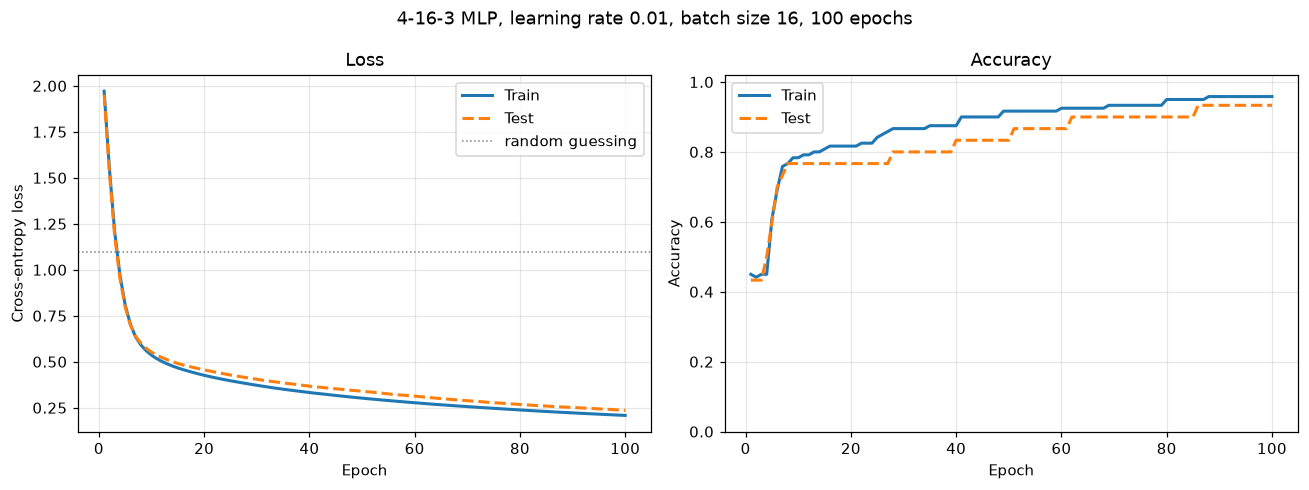

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
epochs_axis = np.arange(1, EPOCHS + 1)

axes[0].plot(epochs_axis, history["train_loss"], label="Train", lw=2)
axes[0].plot(epochs_axis, history["test_loss"], label="Test", lw=2, ls="--")
axes[0].axhline(np.log(3), color="grey", ls=":", lw=1, label="random guessing") 
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(epochs_axis, history["train_acc"], label="Train", lw=2)
axes[1].plot(epochs_axis, history["test_acc"], label="Test", lw=2, ls="--")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy"); axes[1].set_ylim(0, 1.02); axes[1].legend()

fig.suptitle("4-16-3 MLP, learning rate 0.01, batch size 16, 100 epochs")
fig.tight_layout()
plt.savefig("fig_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

 I drew a dotted line at the loss you get from guessing evenly across three classes. I found
the curve starts right there and falls steadily away from it, which tells me
training is working.

The thing I actually noticed is that the loss is still falling at epoch 100. I also see the training and test curves staying close together rather than
drifting apart, which tells me this is not overfitting






## 9. AI Use Statement
I used both Gemini and Claude to conduct research and develop the outline of this project. Furthermore, I used these two AI tools to help me understand the math behind backpropagation and numerical gradient checking. They helped me in polishing the code and providing language editing, feedback according to the rubric of evaluation and also in latex formatting and typesetting of the report.
All final content, calculations are my own.